# Assignment 3 - hybrid biomedical image pipeline

Fluorescence microscopy nuclei dataset. Runs on Colab T4.

Using qwen2.5vl for the image step (mllama install issue on llama3.2-vision,
as per the announcement). Text model is llama3.2. All the LLM calls go
through a local ollama server.


## Setup

In [1]:
!pip install -q scikit-image torch torchvision matplotlib pandas reportlab pypdf


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 31.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 382.9/382.9 kB 21.7 MB/s eta 0:00:00


In [2]:
import os, sys, json, time, random, re, base64, glob, zipfile, shutil, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from skimage import measure, morphology
from skimage.filters import threshold_otsu

SEED = 2026
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

IMG_SIZE = 256
DATA = Path('data/nuclei_dataset')
OUT  = Path('outputs')
OUT.mkdir(exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)


device: cuda


### Dataset

In [3]:
# upload Assingnment-3-dataset-main.zip when the picker opens
DS_ZIP = 'Assingnment-3-dataset-main.zip'
if not Path(DS_ZIP).exists():
    from google.colab import files
    picked = files.upload()
    first = next(iter(picked))
    if first != DS_ZIP:
        shutil.move(first, DS_ZIP)

if not DATA.exists():
    with zipfile.ZipFile(DS_ZIP) as zf:
        zf.extractall('/tmp/ds')
    inner = next(Path('/tmp/ds').rglob('nuclei_dataset.zip'))
    with zipfile.ZipFile(inner) as zf:
        zf.extractall('data')

for s in ('train', 'val', 'test'):
    n = len(list((DATA / s / 'images').glob('*.png')))
    print(f'{s}: {n}')


Saving Assingnment-3-dataset-main.zip to Assingnment-3-dataset-main.zip
train: 80
val: 20
test: 12


### Loading helpers

In [4]:
def read_gray(path):
    # grayscale + resize to 256x256 (brief pins this)
    im = Image.open(path).convert('L').resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    return np.asarray(im, dtype=np.float32) / 255.0

def read_mask(path):
    # nearest for masks so labels don't smear
    im = Image.open(path).convert('L').resize((IMG_SIZE, IMG_SIZE), Image.NEAREST)
    return (np.asarray(im) > 127).astype(np.uint8)

def list_ids(split):
    return sorted(p.stem for p in (DATA / split / 'images').glob('*.png'))

def load_pair(stem, split):
    img  = read_gray(DATA / split / 'images' / f'{stem}.png')
    mask = read_mask(DATA / split / 'masks'  / f'{stem}.png')
    return img, mask

# quick sanity check
img0, m0 = load_pair(list_ids('train')[0], 'train')
print('shape:', img0.shape, 'range:', img0.min(), img0.max(), 'mask sum:', int(m0.sum()))


shape: (256, 256) range: 0.0 0.3529412 mask sum: 1267


## Task 1a - EDA

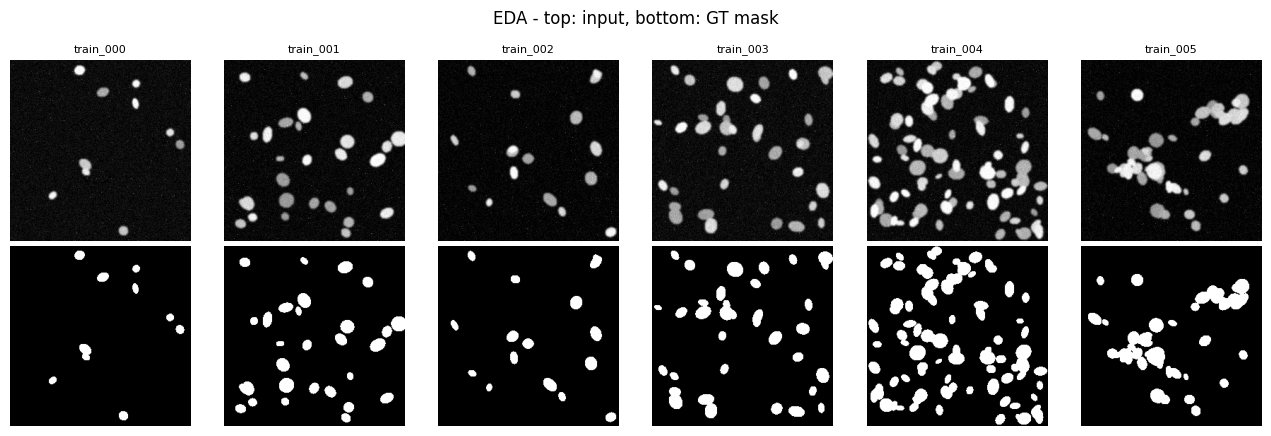

In [5]:
(OUT / 'task1_eda').mkdir(exist_ok=True)

# preview grid: 6 frames, top row image, bottom row mask
train_ids = list_ids('train')
picks = train_ids[:6]

fig, axes = plt.subplots(2, 6, figsize=(13, 4.4))
for j, stem in enumerate(picks):
    img, mask = load_pair(stem, 'train')
    axes[0, j].imshow(img,  cmap='gray'); axes[0, j].set_title(stem, fontsize=8); axes[0, j].axis('off')
    axes[1, j].imshow(mask, cmap='gray'); axes[1, j].axis('off')
fig.suptitle('EDA - top: input, bottom: GT mask')
fig.tight_layout()
fig.savefig(OUT / 'task1_eda' / 'preview_grid.png', dpi=120, bbox_inches='tight')
plt.show()


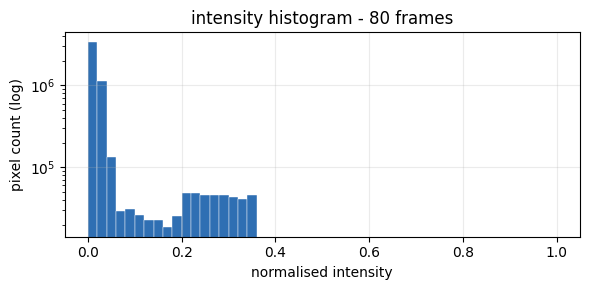

In [6]:
# intensity histogram over the whole train split
# log-y because background dominates
pooled = np.concatenate([read_gray(DATA / 'train' / 'images' / f'{s}.png').ravel()
                         for s in train_ids])

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(pooled, bins=50, range=(0, 1), color='#2f6fb3', edgecolor='white', linewidth=0.3)
ax.set_yscale('log')
ax.set_xlabel('normalised intensity')
ax.set_ylabel('pixel count (log)')
ax.set_title(f'intensity histogram - {len(train_ids)} frames')
ax.grid(alpha=0.25)
fig.tight_layout()
fig.savefig(OUT / 'task1_eda' / 'intensity_hist.png', dpi=120, bbox_inches='tight')
plt.show()


## Task 1b - Multimodal VLM (qwen2.5vl)

In [7]:
# ollama installer needs zstd
!apt-get install -y -qq zstd
!curl -fsSL https://ollama.com/install.sh | sh


Selecting previously unselected package zstd.
(Reading database ... 122492 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [8]:
# start ollama in the background and wait for the API
ollama_proc = subprocess.Popen(['ollama', 'serve'],
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

for _ in range(30):
    try:
        if requests.get('http://localhost:11434/api/tags', timeout=2).ok:
            print('ollama up')
            break
    except Exception:
        pass
    time.sleep(1)


ollama up


In [9]:
!ollama pull qwen2.5vl:7b
!ollama pull llama3.2


In [10]:
VLM_NAME  = 'qwen2.5vl:7b'
TEXT_NAME = 'llama3.2'
OLLAMA_URL = 'http://localhost:11434/api/generate'

def ollama_text(prompt, model=TEXT_NAME, temperature=0.2, seed=None):
    payload = {'model': model, 'prompt': prompt, 'stream': False,
               'options': {'temperature': temperature}}
    if seed is not None:
        payload['options']['seed'] = seed
    r = requests.post(OLLAMA_URL, json=payload, timeout=180)
    r.raise_for_status()
    return r.json().get('response', '')

def ollama_vision(prompt, image_path, model=VLM_NAME, temperature=0.2, seed=None):
    b64 = base64.b64encode(Path(image_path).read_bytes()).decode()
    payload = {'model': model, 'prompt': prompt, 'images': [b64],
               'stream': False, 'options': {'temperature': temperature}}
    if seed is not None:
        payload['options']['seed'] = seed
    r = requests.post(OLLAMA_URL, json=payload, timeout=240)
    r.raise_for_status()
    return r.json().get('response', '')

def extract_json(text):
    # LLMs often wrap JSON in prose or code fences - walk brace-balanced substrings
    if not text:
        return None
    m = re.search(r'```(?:json)?\s*(\{.*?\})\s*```', text, flags=re.DOTALL)
    if m:
        try:
            return json.loads(m.group(1))
        except json.JSONDecodeError:
            pass
    start = text.find('{')
    while start != -1:
        depth = 0
        for j in range(start, len(text)):
            if text[j] == '{': depth += 1
            elif text[j] == '}':
                depth -= 1
                if depth == 0:
                    try:
                        return json.loads(text[start:j+1])
                    except json.JSONDecodeError:
                        break
        start = text.find('{', start + 1)
    return None

# quick ping
print(ollama_text('Reply with just: OK').strip()[:80])


OK


### Prompts

In [11]:
NAIVE_PROMPT = "What is in this medical image? Please describe it."

STRUCTURED_PROMPT = '''You are a careful biomedical image DESCRIPTION assistant.
You are NOT a diagnostician: never name a disease, give a differential, or offer
any clinical advice. Only describe what is visibly present in the image.

Reply requirement: emit ONE JSON object and nothing else - no prose before or after,
no markdown fences. Every field below is REQUIRED. If a field cannot be judged
from the pixels alone, return the string "uncertain" - this is a legitimate answer,
please prefer it over guessing.

Exact schema (do not add or remove keys):
{
  "modality":         "<one of: microscopy | histology | x-ray | ct | mri | ultrasound | fundus | uncertain>",
  "tissue_type":      "<free text of at most six words, or 'uncertain'>",
  "notable_features": "<one short sentence describing visible shapes, sizes, textures or arrangement>",
  "image_quality":    "<one of: good | fair | poor | uncertain>"
}

No disease names. No differentials. No treatment discussion. Emit ONLY the JSON object.'''


In [12]:
(OUT / 'task1_vlm').mkdir(exist_ok=True)

# pick a moderate-density frame
sample_stem = train_ids[3]
sample_path = OUT / 'task1_vlm' / 'representative.png'
Image.fromarray((read_gray(DATA / 'train' / 'images' / f'{sample_stem}.png') * 255).astype(np.uint8)
                ).save(sample_path)
print('using', sample_stem)

# naive
naive_reply = ollama_vision(NAIVE_PROMPT, sample_path, seed=1)
(OUT / 'task1_vlm' / 'naive_reply.txt').write_text(naive_reply)
print('--- NAIVE ---')
print(naive_reply[:600])


using train_003
--- NAIVE ---
The image you provided appears to be a microscopic view of cells, likely taken under a fluorescence microscope. The cells are stained or labeled with a fluorescent dye, which is visible as bright spots or areas against a dark background. The cells seem to be in various shapes, including spherical and elongated, and are distributed throughout the field of view. This type of image is commonly used in biological research to study cell morphology, distribution, and possibly the localization of specific proteins or molecules within the cells. The specific type of cells and the purpose of the staini


In [13]:
# structured
structured_reply = ollama_vision(STRUCTURED_PROMPT, sample_path, seed=1)
(OUT / 'task1_vlm' / 'structured_reply.txt').write_text(structured_reply)

parsed = extract_json(structured_reply)
with open(OUT / 'task1_vlm' / 'structured_parsed.json', 'w') as f:
    json.dump(parsed or {'error': 'no json'}, f, indent=2)

print('--- STRUCTURED ---')
print(structured_reply[:600])
print('\nparsed:', parsed)


--- STRUCTURED ---
{
  "modality": "microscopy",
  "tissue_type": "uncertain",
  "notable_features": "Small, rounded, and slightly elongated structures with varying sizes and faint textures.",
  "image_quality": "good"
}

parsed: {'modality': 'microscopy', 'tissue_type': 'uncertain', 'notable_features': 'Small, rounded, and slightly elongated structures with varying sizes and faint textures.', 'image_quality': 'good'}


In [14]:
# 3 repeated runs, no fixed seed, to demonstrate variability
repeats = []
for i in range(3):
    r = ollama_vision(STRUCTURED_PROMPT, sample_path)
    repeats.append({'run': i+1, 'parsed': extract_json(r), 'raw_head': r[:250]})
with open(OUT / 'task1_vlm' / 'repeats.json', 'w') as f:
    json.dump(repeats, f, indent=2)

for r in repeats:
    print(f"run {r['run']}: {r['parsed']}")


run 1: {'modality': 'microscopy', 'tissue_type': 'uncertain', 'notable_features': 'Small, rounded, and slightly elongated structures with varying intensities.', 'image_quality': 'good'}
run 2: {'modality': 'microscopy', 'tissue_type': 'uncertain', 'notable_features': 'Small, rounded, and slightly elongated structures with varying intensities against a dark background.', 'image_quality': 'good'}
run 3: {'modality': 'microscopy', 'tissue_type': 'uncertain', 'notable_features': 'Small, oval-shaped structures scattered across a dark background.', 'image_quality': 'good'}


## Task 2 - Classical features + numbers-first LLM

In [15]:
FEATURE_COLS = ('label', 'area', 'eccentricity', 'solidity',
                'mean_intensity', 'perimeter', 'equivalent_diameter',
                'extent', 'orientation')

def otsu_mask(image, min_size=15, close_radius=1):
    # bright nuclei on dark bg -> otsu >= threshold. handle flat frames.
    if image.max() - image.min() < 1e-6:
        return np.zeros_like(image, dtype=np.uint8)
    thr = threshold_otsu(image)
    m = image >= thr
    m = morphology.remove_small_objects(m, min_size=min_size)
    if close_radius > 0:
        m = morphology.closing(m, footprint=morphology.disk(close_radius))
    return m.astype(np.uint8)

def region_table(mask, intensity):
    lab = measure.label(mask, connectivity=2)
    if lab.max() == 0:
        return pd.DataFrame(columns=list(FEATURE_COLS)), lab
    raw = measure.regionprops_table(lab, intensity_image=intensity,
                                    properties=FEATURE_COLS)
    return pd.DataFrame(raw), lab

def digest(props, image_shape):
    # compact natural-language summary of the per-object table
    n = len(props)
    if n == 0:
        return 'The segmented image contains 0 detected objects; background only.'
    return (f'The segmented image contains {n} objects. '
            f'Mean area {props["area"].mean():.1f} px (median {props["area"].median():.1f}). '
            f'Mean eccentricity {props["eccentricity"].mean():.2f} '
            f'(0=circular, 1=elongated); mean solidity '
            f'{props["solidity"].mean():.2f} (1=convex/regular). '
            f'Mean intensity inside objects {props["mean_intensity"].mean():.2f} '
            f'on 0-1 scale. Foreground {props["area"].sum() / (image_shape[0]*image_shape[1]) * 100:.1f}% of the frame.')


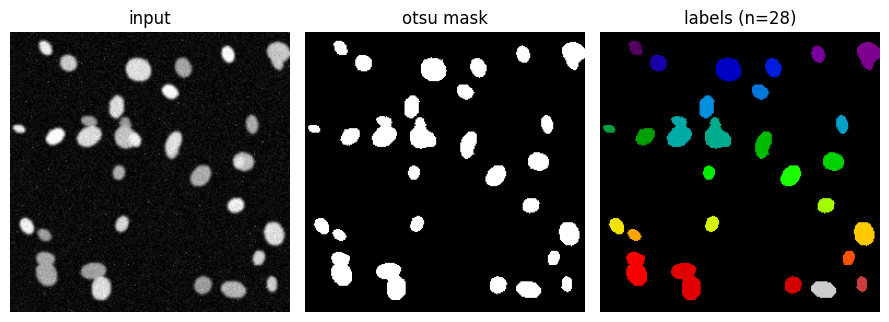

The segmented image contains 28 objects. Mean area 242.1 px (median 201.0). Mean eccentricity 0.64 (0=circular, 1=elongated); mean solidity 0.94 (1=convex/regular). Mean intensity inside objects 0.25 on 0-1 scale. Foreground 10.3% of the frame.


In [16]:
(OUT / 'task2_classical').mkdir(exist_ok=True)

# run on the same representative frame as Task 1b
img, _ = load_pair(sample_stem, 'train')
mask = otsu_mask(img)
props, labelled = region_table(mask, img)
props.to_csv(OUT / 'task2_classical' / 'region_table.csv', index=False)

# triptych
fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
axes[0].imshow(img, cmap='gray'); axes[0].set_title('input'); axes[0].axis('off')
axes[1].imshow(mask, cmap='gray'); axes[1].set_title('otsu mask'); axes[1].axis('off')
axes[2].imshow(labelled, cmap='nipy_spectral'); axes[2].set_title(f'labels (n={int(labelled.max())})'); axes[2].axis('off')
fig.tight_layout()
fig.savefig(OUT / 'task2_classical' / 'triptych.png', dpi=120, bbox_inches='tight')
plt.show()

digest_text = digest(props, img.shape)
(OUT / 'task2_classical' / 'digest.txt').write_text(digest_text)
print(digest_text)


In [17]:
TASK2_PROMPT = f'''You are a scientific-writing assistant. You are given ONLY
a numerical digest derived from an image (Otsu + regionprops). You cannot see
the image. Do not invent facts not in the digest.

Numerical digest:
{digest_text}

Produce EXACTLY two blocks, in this order:

BLOCK A: a short paragraph (2-4 sentences) describing what the numbers imply
about the scene. Do NOT diagnose. Prefer "uncertain" over any guess.

BLOCK B: on a new line, one JSON object and NOTHING AFTER IT, with this exact
schema:

{{
  "n_objects":        <integer>,
  "density_class":    "<one of: sparse | moderate | dense | uncertain>",
  "shape_regularity": "<one of: regular | mixed | irregular | uncertain>",
  "quality_flag":     "<one of: good | fair | poor | uncertain>"
}}

Order is strict: paragraph then JSON. Nothing else.'''

(OUT / 'task2_classical' / 'prompt.txt').write_text(TASK2_PROMPT)

reply = ollama_text(TASK2_PROMPT, seed=1)
(OUT / 'task2_classical' / 'reply.txt').write_text(reply)

parsed = extract_json(reply)
with open(OUT / 'task2_classical' / 'parsed.json', 'w') as f:
    json.dump(parsed or {}, f, indent=2)

print(reply[:600])
print('\nparsed:', parsed)


BLOCK A:
The numerical digest provides some insight into the characteristics of the segmented objects in the image. The mean area of 242.1 px and median area of 201.0 suggest a range of object sizes, while the mean eccentricity of 0.64 indicates that the objects are not perfectly circular. The high solidity of 0.94 implies that the objects are likely convex or regular in shape. However, without further information, it is uncertain what these characteristics imply about the scene.

{
  "n_objects":        28,
  "density_class":    "dense",
  "shape_regularity": "irregular",
  "quality_flag":   

parsed: None


## Task 3 - U-Net segmentation

In [18]:
def double_conv(cin, cout):
    return nn.Sequential(
        nn.Conv2d(cin, cout, 3, padding=1, bias=False),
        nn.BatchNorm2d(cout),
        nn.ReLU(inplace=True),
        nn.Conv2d(cout, cout, 3, padding=1, bias=False),
        nn.BatchNorm2d(cout),
        nn.ReLU(inplace=True),
    )

class NucleiUNet(nn.Module):
    # 4-level unet, base=16 -> ~1.9M params. same-pad 3x3 convs. returns logits.
    def __init__(self, base=16):
        super().__init__()
        self.enc1 = double_conv(1, base)
        self.enc2 = double_conv(base, base*2)
        self.enc3 = double_conv(base*2, base*4)
        self.enc4 = double_conv(base*4, base*8)
        self.pool = nn.MaxPool2d(2)
        self.bot  = double_conv(base*8, base*16)
        self.up4 = nn.ConvTranspose2d(base*16, base*8, 2, stride=2)
        self.dec4 = double_conv(base*16, base*8)
        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.dec3 = double_conv(base*8, base*4)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec2 = double_conv(base*4, base*2)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.dec1 = double_conv(base*2, base)
        self.head = nn.Conv2d(base, 1, 1)

    def forward(self, x):
        s1 = self.enc1(x)
        s2 = self.enc2(self.pool(s1))
        s3 = self.enc3(self.pool(s2))
        s4 = self.enc4(self.pool(s3))
        b  = self.bot(self.pool(s4))
        d4 = self.dec4(torch.cat([self.up4(b),  s4], 1))
        d3 = self.dec3(torch.cat([self.up3(d4), s3], 1))
        d2 = self.dec2(torch.cat([self.up2(d3), s2], 1))
        d1 = self.dec1(torch.cat([self.up1(d2), s1], 1))
        return self.head(d1)

net = NucleiUNet()
n_params = sum(p.numel() for p in net.parameters())
print(f'{n_params:,} params')


1,942,289 params


In [19]:
class NucleiDataset(Dataset):
    def __init__(self, split, augment=False):
        self.split = split
        self.stems = list_ids(split)
        self.augment = augment

    def __len__(self):
        return len(self.stems)

    def __getitem__(self, i):
        stem = self.stems[i]
        img, mask = load_pair(stem, self.split)
        mask = mask.astype(np.float32)
        if self.augment:
            # flips + right-angle rotations, same op to image and mask
            if random.random() < 0.5:
                img = img[:, ::-1].copy(); mask = mask[:, ::-1].copy()
            if random.random() < 0.5:
                img = img[::-1, :].copy(); mask = mask[::-1, :].copy()
            k = random.randint(0, 3)
            if k:
                img = np.rot90(img, k).copy(); mask = np.rot90(mask, k).copy()
        return (torch.from_numpy(img).unsqueeze(0),
                torch.from_numpy(mask).unsqueeze(0),
                stem)


In [20]:
def dice_score(pred, target, eps=1e-6):
    p = np.asarray(pred).astype(bool)
    t = np.asarray(target).astype(bool)
    inter = np.logical_and(p, t).sum()
    total = p.sum() + t.sum()
    if total == 0: return 1.0
    return float((2 * inter + eps) / (total + eps))

def iou_score(pred, target, eps=1e-6):
    p = np.asarray(pred).astype(bool)
    t = np.asarray(target).astype(bool)
    inter = np.logical_and(p, t).sum()
    union = np.logical_or(p, t).sum()
    if union == 0: return 1.0
    return float((inter + eps) / (union + eps))

def soft_dice_loss(logits, target, eps=1e-6):
    prob = torch.sigmoid(logits)
    dims = (1, 2, 3)
    inter = (prob * target).sum(dim=dims)
    total = prob.sum(dim=dims) + target.sum(dim=dims)
    return 1.0 - ((2 * inter + eps) / (total + eps)).mean()

def make_loss(name):
    if name == 'bce':
        return nn.BCEWithLogitsLoss()
    if name == 'dice':
        return soft_dice_loss
    if name == 'bce_dice':
        bce = nn.BCEWithLogitsLoss()
        return lambda lo, t: 0.5 * bce(lo, t) + 0.5 * soft_dice_loss(lo, t)
    raise ValueError(name)


In [21]:
def train_unet(loss_name='bce_dice', epochs=20, lr=1e-3, batch=4, base=16, log=True):
    train_ds = NucleiDataset('train', augment=True)
    val_ds   = NucleiDataset('val',   augment=False)
    train_loader = DataLoader(train_ds, batch_size=batch, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch, shuffle=False)

    net = NucleiUNet(base=base).to(DEVICE)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    loss_fn = make_loss(loss_name)

    hist = {'train_loss': [], 'val_loss': [], 'val_dice': [], 'val_iou': []}

    for ep in range(1, epochs + 1):
        net.train()
        total = 0
        for x, y, _ in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            lo = net(x)
            loss = loss_fn(lo, y)
            loss.backward()
            opt.step()
            total += loss.item() * x.size(0)
        hist['train_loss'].append(total / len(train_ds))

        # val
        net.eval()
        vloss, dices, ious = 0, [], []
        with torch.no_grad():
            for x, y, _ in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                lo = net(x)
                vloss += loss_fn(lo, y).item() * x.size(0)
                pred = (torch.sigmoid(lo) > 0.5).cpu().numpy().astype(np.uint8)
                true = y.cpu().numpy().astype(np.uint8)
                for pi, ti in zip(pred, true):
                    dices.append(dice_score(pi[0], ti[0]))
                    ious.append(iou_score (pi[0], ti[0]))
        hist['val_loss'].append(vloss / len(val_ds))
        hist['val_dice'].append(float(np.mean(dices)))
        hist['val_iou' ].append(float(np.mean(ious)))

        if log:
            print(f"ep {ep:3d}  train {hist['train_loss'][-1]:.4f}  "
                  f"val {hist['val_loss'][-1]:.4f}  "
                  f"dice {hist['val_dice'][-1]:.4f}  "
                  f"iou {hist['val_iou'][-1]:.4f}")

    return net, hist


In [22]:
# main model: bce_dice, 20 epochs
net_main, hist_main = train_unet('bce_dice', epochs=20)
torch.save(net_main.state_dict(), OUT.parent / 'unet_bce_dice.pt')

(OUT / 'task3_unet').mkdir(exist_ok=True)
with open(OUT / 'task3_unet' / 'history_bce_dice.json', 'w') as f:
    json.dump(hist_main, f, indent=2)


ep   1  train 0.6877  val 0.7313  dice 0.9157  iou 0.8451
ep   2  train 0.6224  val 0.6151  dice 0.8828  iou 0.7905
ep   3  train 0.5805  val 0.5618  dice 0.9240  iou 0.8590
ep   4  train 0.5460  val 0.5223  dice 0.9524  iou 0.9092
ep   5  train 0.5132  val 0.4913  dice 0.9608  iou 0.9247
ep   6  train 0.4802  val 0.5283  dice 0.7573  iou 0.6848
ep   7  train 0.4477  val 0.4261  dice 0.9895  iou 0.9793
ep   8  train 0.4161  val 0.4554  dice 0.9886  iou 0.9774
ep   9  train 0.3843  val 0.3766  dice 0.9841  iou 0.9688
ep  10  train 0.3558  val 0.3578  dice 0.9876  iou 0.9755
ep  11  train 0.3258  val 0.3184  dice 0.9907  iou 0.9815
ep  12  train 0.2970  val 0.2992  dice 0.9949  iou 0.9898
ep  13  train 0.2670  val 0.2740  dice 0.9952  iou 0.9905
ep  14  train 0.2403  val 0.2443  dice 0.9916  iou 0.9834
ep  15  train 0.2149  val 0.2057  dice 0.9958  iou 0.9916
ep  16  train 0.1881  val 0.1918  dice 0.9925  iou 0.9852
ep  17  train 0.1570  val 0.1426  dice 0.9952  iou 0.9905
ep  18  train 

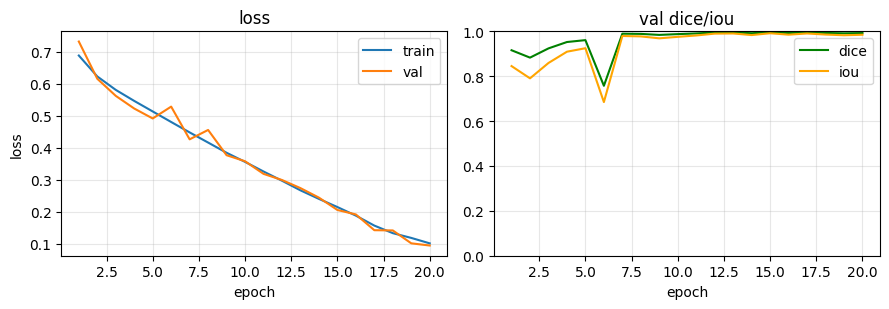

In [23]:
# curves
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))
xs = np.arange(1, len(hist_main['train_loss']) + 1)
axes[0].plot(xs, hist_main['train_loss'], label='train')
axes[0].plot(xs, hist_main['val_loss'],   label='val')
axes[0].set_xlabel('epoch'); axes[0].set_ylabel('loss'); axes[0].set_title('loss')
axes[0].grid(alpha=0.3); axes[0].legend()

axes[1].plot(xs, hist_main['val_dice'], label='dice', color='green')
axes[1].plot(xs, hist_main['val_iou'],  label='iou',  color='orange')
axes[1].set_xlabel('epoch'); axes[1].set_ylim(0, 1); axes[1].set_title('val dice/iou')
axes[1].grid(alpha=0.3); axes[1].legend()

fig.tight_layout()
fig.savefig(OUT / 'task3_unet' / 'curves_bce_dice.png', dpi=120, bbox_inches='tight')
plt.show()


In [24]:
# per-image val metrics
@torch.no_grad()
def evaluate(net, split='val'):
    net.eval().to(DEVICE)
    per_stem = {}
    ds = NucleiDataset(split, augment=False)
    loader = DataLoader(ds, batch_size=4, shuffle=False)
    for x, y, stems in loader:
        x = x.to(DEVICE)
        pred = (torch.sigmoid(net(x)) > 0.5).cpu().numpy().astype(np.uint8)
        true = y.numpy().astype(np.uint8)
        for i, s in enumerate(stems):
            per_stem[s] = (dice_score(pred[i, 0], true[i, 0]),
                           iou_score (pred[i, 0], true[i, 0]))
    return per_stem

per_stem = evaluate(net_main, 'val')
mean_dice = np.mean([d for d, _ in per_stem.values()])
mean_iou  = np.mean([i for _, i in per_stem.values()])
print(f'\nval mean dice = {mean_dice:.4f}, mean iou = {mean_iou:.4f}')

with open(OUT / 'task3_unet' / 'metrics_bce_dice.json', 'w') as f:
    json.dump({'mean_dice': float(mean_dice), 'mean_iou': float(mean_iou),
               'per_image': {s: {'dice': d, 'iou': i}
                             for s, (d, i) in per_stem.items()}}, f, indent=2)



val mean dice = 0.9923, mean iou = 0.9848


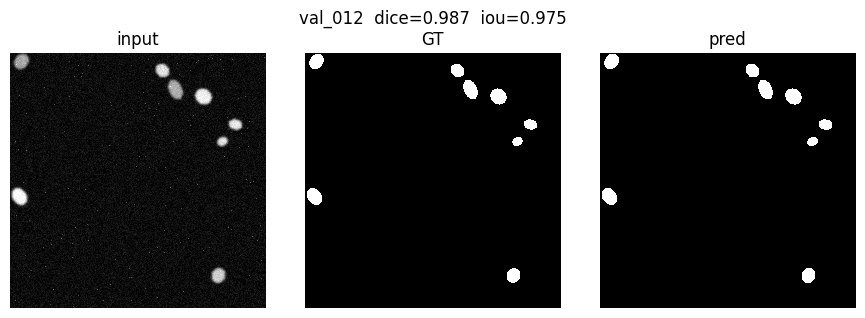

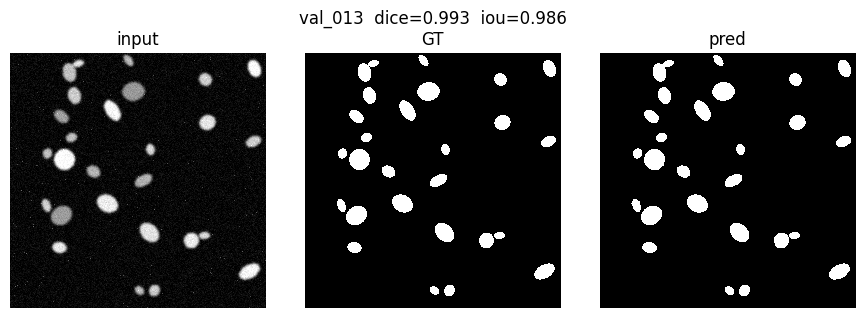

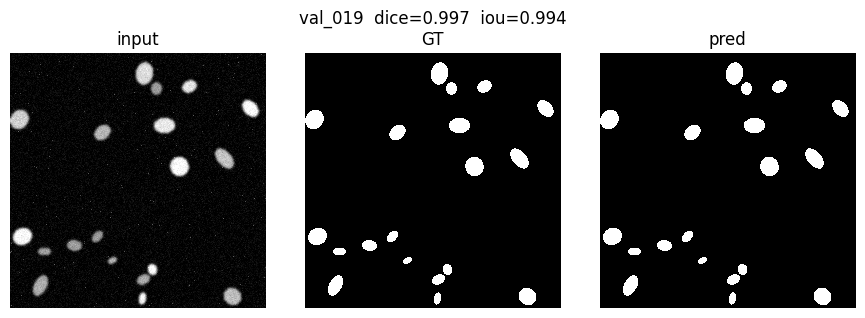

In [25]:
# worst / median / best triptychs
(OUT / 'task3_unet' / 'panels').mkdir(exist_ok=True)

def predict_one(net, img):
    net.eval().to(DEVICE)
    with torch.no_grad():
        t = torch.from_numpy(img.astype(np.float32)).unsqueeze(0).unsqueeze(0).to(DEVICE)
        return (torch.sigmoid(net(t))[0, 0].cpu().numpy() > 0.5).astype(np.uint8)

ranked = sorted(per_stem.items(), key=lambda kv: kv[1][0])
picks_val = [ranked[0], ranked[len(ranked) // 2], ranked[-1]]

for stem, (d, i) in picks_val:
    img, mask = load_pair(stem, 'val')
    pred = predict_one(net_main, img)
    fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
    axes[0].imshow(img,  cmap='gray'); axes[0].set_title('input');  axes[0].axis('off')
    axes[1].imshow(mask, cmap='gray'); axes[1].set_title('GT');     axes[1].axis('off')
    axes[2].imshow(pred, cmap='gray'); axes[2].set_title('pred');   axes[2].axis('off')
    fig.suptitle(f'{stem}  dice={d:.3f}  iou={i:.3f}')
    fig.tight_layout()
    fig.savefig(OUT / 'task3_unet' / 'panels' / f'{stem}.png', dpi=120, bbox_inches='tight')
    plt.show()


## Task 4 - Hybrid pipeline (unseen test split)

U-Net mask -> regionprops -> digest -> LLM -> strict JSON per frame ->
aggregate into a single CSV. The Task 4 deliverable.


In [26]:
def hybrid_prompt(image_id, digest_text):
    return f'''You are a scientific-writing assistant. Given a numerical digest
of measurements from an automated U-Net segmentation of image \'{image_id}\'.
You cannot see the image. Do NOT invent facts not in the digest.

Numerical digest:
{digest_text}

Produce EXACTLY two blocks, in this order:

BLOCK A: one-paragraph narrative (2-4 sentences) describing what the numbers
imply about the scene. Do NOT diagnose. Prefer "uncertain" over any guess.

BLOCK B: on a new line, one JSON object and NOTHING AFTER IT, with this
exact schema:

{{
  "image_id":      "{image_id}",
  "n_objects":     <integer>,
  "mean_area":     <number, pixels>,
  "density_class": "<one of: sparse | moderate | dense | uncertain>",
  "quality_flag":  "<one of: good | fair | poor | uncertain>"
}}

Order is strict: paragraph then JSON. Nothing else.'''

def bucket_density(n):
    if n <= 5:  return 'sparse'
    if n <= 20: return 'moderate'
    return 'dense'

def guess_quality(img):
    c = float(img.std())
    if c < 0.02: return 'poor'
    if c < 0.06: return 'fair'
    return 'good'


In [27]:
(OUT / 'task4_hybrid').mkdir(exist_ok=True)
(OUT / 'task4_hybrid' / 'records').mkdir(exist_ok=True)

rows = []
for stem in list_ids('test'):
    img = read_gray(DATA / 'test' / 'images' / f'{stem}.png')
    pred = predict_one(net_main, img)
    props, _ = region_table(pred, img)
    d = digest(props, img.shape)

    prompt = hybrid_prompt(stem, d)
    reply = ollama_text(prompt, seed=1)
    parsed = extract_json(reply) or {}

    row = {
        'image_id':      stem,
        'n_objects':     int  (parsed.get('n_objects',     len(props))),
        'mean_area':     float(parsed.get('mean_area')     or (props['area'].mean() if len(props) else 0.0)),
        'density_class': str  (parsed.get('density_class') or bucket_density(len(props))),
        'quality_flag':  str  (parsed.get('quality_flag')  or guess_quality(img)),
        'narrative':     reply.split('{')[0].strip() if '{' in reply else reply.strip(),
    }
    rows.append(row)

    # per-image full record for audit
    with open(OUT / 'task4_hybrid' / 'records' / f'{stem}.json', 'w') as f:
        json.dump({**row, 'raw_reply': reply, 'digest': d}, f, indent=2)

df = pd.DataFrame(rows)
df.to_csv(OUT / 'task4_hybrid' / 'aggregated.csv', index=False)
print(f'\n{len(df)} rows written')
df.drop(columns=['narrative'])



12 rows written


,image_id,n_objects,mean_area,density_class,quality_flag
0,test_000,8,194.125000,moderate,fair
1,test_001,14,204.857143,moderate,fair
2,test_002,25,231.200000,dense,good
3,test_003,19,207.947368,moderate,good
4,test_004,42,339.738095,dense,good
5,test_005,15,438.666667,moderate,good
6,test_006,8,202.250000,moderate,fair
7,test_007,23,208.304348,dense,good
8,test_008,23,241.826087,dense,good
9,test_009,21,182.095238,dense,fair


In [28]:
# example narrative
print(df.iloc[0]['image_id'])
print(df.iloc[0]['narrative'])


test_000
BLOCK A:
The numerical digest provides information about the segmentation of the image 'test_000'. The presence of 8 objects suggests a complex scene, but the exact nature of these objects is unclear. The mean area and solidity values indicate a relatively regular shape, while the mean eccentricity suggests some elongation. The low intensity inside objects and high foreground percentage may imply a scene with a clear distinction between the objects and the background.


## Extensions

(A) U-Net vs Otsu on val, (B) loss ablation, (C) robustness trace.


### (A) U-Net vs Otsu

In [29]:
(OUT / 'ext_a').mkdir(exist_ok=True)

rows_a = []
for stem in list_ids('val'):
    img, gt = load_pair(stem, 'val')
    pu = predict_one(net_main, img)
    po = otsu_mask(img)
    rows_a.append({
        'image_id':  stem,
        'dice_unet': dice_score(pu, gt),
        'iou_unet':  iou_score (pu, gt),
        'dice_otsu': dice_score(po, gt),
        'iou_otsu':  iou_score (po, gt),
    })

df_a = pd.DataFrame(rows_a)
df_a.loc['mean'] = df_a[['dice_unet','iou_unet','dice_otsu','iou_otsu']].mean()
df_a.loc['mean', 'image_id'] = 'MEAN'
df_a.to_csv(OUT / 'ext_a' / 'unet_vs_otsu.csv', index=False)

print(f"mean dice: unet={df_a.loc['mean','dice_unet']:.4f}  otsu={df_a.loc['mean','dice_otsu']:.4f}")
print(f"mean iou:  unet={df_a.loc['mean','iou_unet' ]:.4f}  otsu={df_a.loc['mean','iou_otsu' ]:.4f}")


mean dice: unet=0.9923  otsu=0.9778
mean iou:  unet=0.9848  otsu=0.9565


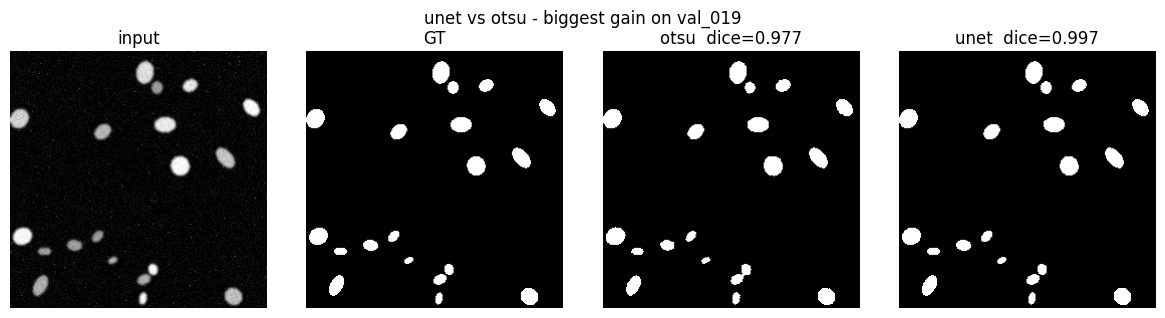

In [30]:
# comparison figure for the biggest U-Net win
body = df_a[df_a['image_id'] != 'MEAN'].copy()
body['gain'] = body['dice_unet'] - body['dice_otsu']
winner = body.loc[body['gain'].idxmax(), 'image_id']

img, gt = load_pair(winner, 'val')
pu = predict_one(net_main, img)
po = otsu_mask(img)

fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
axes[0].imshow(img, cmap='gray'); axes[0].set_title('input'); axes[0].axis('off')
axes[1].imshow(gt,  cmap='gray'); axes[1].set_title('GT');    axes[1].axis('off')
axes[2].imshow(po,  cmap='gray'); axes[2].set_title(f'otsu  dice={dice_score(po, gt):.3f}'); axes[2].axis('off')
axes[3].imshow(pu,  cmap='gray'); axes[3].set_title(f'unet  dice={dice_score(pu, gt):.3f}'); axes[3].axis('off')
fig.suptitle(f'unet vs otsu - biggest gain on {winner}')
fig.tight_layout()
fig.savefig(OUT / 'ext_a' / f'compare_{winner}.png', dpi=120, bbox_inches='tight')
plt.show()


### (B) Loss ablation - bce vs dice vs bce+dice

In [31]:
(OUT / 'ext_b').mkdir(exist_ok=True)

# already have bce_dice from earlier
ablation = {'bce_dice': (float(mean_dice), float(mean_iou))}

for ln in ('bce', 'dice'):
    print(f'\n--- training {ln} ---')
    n, h = train_unet(ln, epochs=12, log=False)
    ps = evaluate(n, 'val')
    md_val = float(np.mean([d for d, _ in ps.values()]))
    mi_val = float(np.mean([i for _, i in ps.values()]))
    ablation[ln] = (md_val, mi_val)
    print(f'{ln}: dice={md_val:.4f}  iou={mi_val:.4f}')

ab_df = pd.DataFrame([{'loss': k, 'dice': v[0], 'iou': v[1]}
                      for k, v in ablation.items()]).sort_values('dice', ascending=False)
ab_df.to_csv(OUT / 'ext_b' / 'ablation.csv', index=False)
print()
print(ab_df.to_string(index=False))



--- training bce ---
bce: dice=0.9955  iou=0.9910

--- training dice ---
dice: dice=0.9945  iou=0.9891

    loss     dice      iou
     bce 0.995475 0.990993
    dice 0.994511 0.989087
bce_dice 0.992318 0.984770


### (C) Robustness trace

In [32]:
(OUT / 'ext_c').mkdir(exist_ok=True)

corrupt_dir = DATA / 'test_corrupted' / 'images'
corrupt_stems = sorted(p.stem for p in corrupt_dir.glob('*.png'))
base_ids = sorted({s.rsplit('_', 1)[0] for s in corrupt_stems})

rows_c = []
for base in base_ids:
    variants = [('clean', read_gray(DATA / 'test' / 'images' / f'{base}.png'), base)]
    for suf in ('blur', 'lowcontrast', 'noise'):
        p = corrupt_dir / f'{base}_{suf}.png'
        if p.exists():
            variants.append((suf, read_gray(p), p.stem))

    for tag, img, iid in variants:
        pred = predict_one(net_main, img)
        props, _ = region_table(pred, img)
        d = digest(props, img.shape)
        prompt = hybrid_prompt(iid, d)
        reply = ollama_text(prompt, seed=1)
        parsed = extract_json(reply) or {}
        rows_c.append({
            'base': base, 'variant': tag, 'image_id': iid,
            'mask_fg_frac': float(pred.mean()),
            'n_objects': len(props),
            'mean_area': float(props['area'].mean()) if len(props) else 0.0,
            'density_class': parsed.get('density_class', 'n/a'),
            'quality_flag':  parsed.get('quality_flag',  'n/a'),
        })

df_c = pd.DataFrame(rows_c)
df_c.to_csv(OUT / 'ext_c' / 'robustness.csv', index=False)
print(df_c[['base','variant','mask_fg_frac','n_objects','density_class','quality_flag']].to_string(index=False))


    base     variant  mask_fg_frac  n_objects density_class quality_flag
test_000       clean      0.023697          8           n/a          n/a
test_000        blur      0.038757          7           n/a          n/a
test_000 lowcontrast      0.999985          1           n/a          n/a
test_004       clean      0.217728         42           n/a          n/a
test_004        blur      0.444489          9           n/a          n/a
test_004 lowcontrast      0.999985          1           n/a          n/a


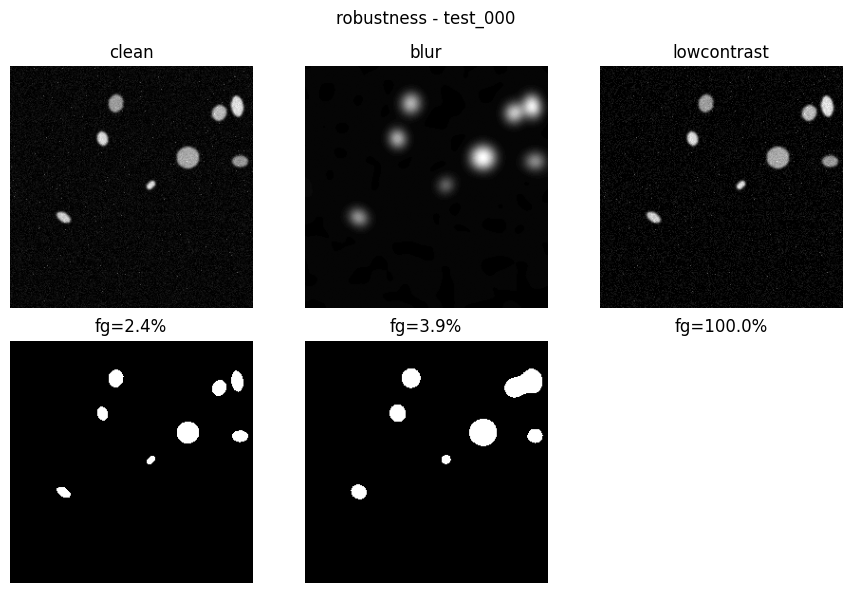

In [33]:
# visual comparison for the low-contrast failure
show_base = base_ids[0]
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for j, (suf, title) in enumerate([('', 'clean'), ('_blur', 'blur'), ('_lowcontrast', 'lowcontrast')]):
    path = corrupt_dir / f'{show_base}{suf}.png' if suf else DATA / 'test' / 'images' / f'{show_base}.png'
    if not path.exists():
        axes[0, j].axis('off'); axes[1, j].axis('off'); continue
    img = read_gray(path)
    pred = predict_one(net_main, img)
    axes[0, j].imshow(img,  cmap='gray'); axes[0, j].set_title(title); axes[0, j].axis('off')
    axes[1, j].imshow(pred, cmap='gray'); axes[1, j].set_title(f'fg={pred.mean()*100:.1f}%'); axes[1, j].axis('off')
fig.suptitle(f'robustness - {show_base}')
fig.tight_layout()
fig.savefig(OUT / 'ext_c' / f'panels_{show_base}.png', dpi=120, bbox_inches='tight')
plt.show()


## Download

In [34]:
# zip everything under outputs/ + this notebook's data files
OUT_ZIP = 'microlens_outputs.zip'
if Path(OUT_ZIP).exists():
    Path(OUT_ZIP).unlink()

with zipfile.ZipFile(OUT_ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in Path('outputs').rglob('*'):
        if f.is_file():
            zf.write(f, str(f.relative_to('.')))
    if Path('unet_bce_dice.pt').exists():
        zf.write('unet_bce_dice.pt')

print(f'{OUT_ZIP}: {Path(OUT_ZIP).stat().st_size / 1e6:.1f} MB')

try:
    from google.colab import files
    files.download(OUT_ZIP)
except ImportError:
    print(Path(OUT_ZIP).resolve())


microlens_outputs.zip: 8.7 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>